Практическая работа №4: Решение уравнений методом хорд и касательных

In [ ]:
# Импорт необходимых библиотек
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
import math

# Настройка отображения графиков
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

задание 1

Интервалы, где функция меняет знак:
------------------------------------------------------------
[1.377, 1.378] -> f(1.377) = -0.000, f(1.378) = 0.002


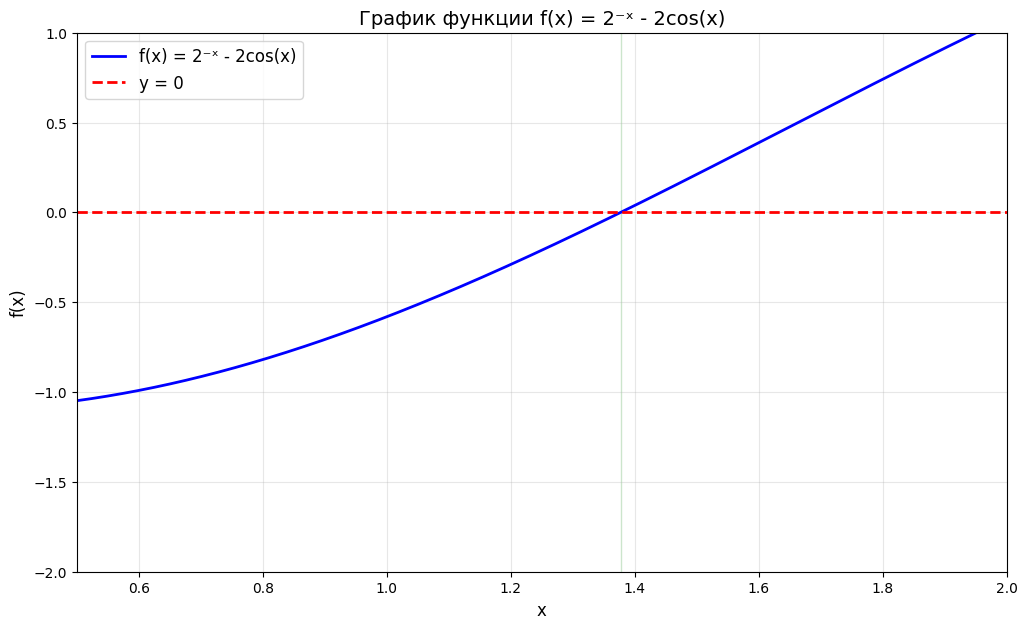


Найденные интервалы с корнями:
Корень 1: x ∈ [1.377, 1.378]

Для уточнения выбираем интервал [1.377, 1.378]


In [6]:
def f2(x):
    """Исходная функция для работы №2"""
    return 2**(-x) - 2 * np.cos(x)

# Создаем массив значений x
x_vals = np.linspace(0.5, 2.0, 1000)
y_vals = f2(x_vals)

# Построение графика
plt.figure(figsize=(12, 7))
plt.plot(x_vals, y_vals, 'b-', linewidth=2, label='f(x) = 2⁻ˣ - 2cos(x)')
plt.axhline(y=0, color='r', linestyle='--', linewidth=2, label='y = 0')
plt.axvline(x=0, color='k', linestyle='-', linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.title('График функции f(x) = 2⁻ˣ - 2cos(x)', fontsize=14)
plt.legend(fontsize=12)
plt.xlim(0.5, 2.0)
plt.ylim(-2, 1)

# Находим интервалы, где функция меняет знак
intervals = []
print("Интервалы, где функция меняет знак:")
print("-" * 60)

for i in range(len(x_vals)-1):
    if y_vals[i] * y_vals[i+1] < 0:
        a, b = x_vals[i], x_vals[i+1]
        intervals.append((a, b))
        plt.axvspan(a, b, alpha=0.2, color='green')
        print(f"[{a:.3f}, {b:.3f}] -> f({a:.3f}) = {y_vals[i]:.3f}, f({b:.3f}) = {y_vals[i+1]:.3f}")

plt.show()

print("\nНайденные интервалы с корнями:")
for i, (a, b) in enumerate(intervals, 1):
    print(f"Корень {i}: x ∈ [{a:.3f}, {b:.3f}]")

# Выбираем интервал для дальнейшего уточнения
a0, b0 = intervals[0]
print(f"\nДля уточнения выбираем интервал [{a0:.3f}, {b0:.3f}]")

задание 2:

In [ ]:
import numpy as np

# Определяем функцию и её производную для демонстрации
def f_demo(x):
    """Исправлено: используется обычный дефис, а не типографский минус."""
    return 2**(-x) - 2 * np.cos(x)

def df_demo(x):
    """Производная функции f_demo."""
    return -2**(-x) * np.log(2) + 2 * np.sin(x)

def chord_method(a, b, eps):
    """
    Находит корень уравнения f_demo(x)=0 на отрезке [a, b] методом хорд.
    """
    print("\n" + "="*60)
    print("Задание 2 : Метод хорд для уравнения 2^(-x) - 2cos(x) = 0")
    print("="*60)

    if f_demo(a) * f_demo(b) >= 0:
        print(f"Метод хорд не применим: f({a:.3f}) = {f_demo(a):.3f} и f({b:.3f}) = {f_demo(b):.3f} одного знака.")
        return None

    print("\nТаблица итераций метода хорд:")
    print("┌─────┬───────────┬───────────┬───────────┬───────────┬───────────┐")
    print("│  n  │     a     │     b     │     x     │   f(x)    │  |b-a|    │")
    print("├─────┼───────────┼───────────┼───────────┼───────────┼───────────┤")

    n = 0
    while True:
        fa = f_demo(a)
        fb = f_demo(b)
        x = (a * fb - b * fa) / (fb - fa)
        fx = f_demo(x)

        print(f"│ {n:3d} │ {a:9.6f} │ {b:9.6f} │ {x:9.6f} │ {fx:9.6f} │ {abs(b-a):9.6f} │")

        if abs(fx) < eps:
            break

        if fa * fx < 0:
            b = x
        else:
            a = x
        n += 1

        # Предотвращение бесконечного цикла
        if n > 50:
            print("│     │           │           │           │           │           │")
            print("└─────┴───────────┴───────────┴───────────┴───────────┴───────────┘")
            print("\nДостигнуто максимальное число итераций (50).")
            break
    else:
        print("└─────┴───────────┴───────────┴───────────┴───────────┴───────────┘")

    print(f"\nРезультат:")
    print(f"Корень x = {x:.6f}")
    print(f"Значение функции f(x) = {fx:.6f}")
    print(f"Число итераций: {n+1}")
    return x

# Запуск метода с начальным отрезком [1, 2]
eps = 0.001
root_chord = chord_method(1.0, 2.0, eps)


Задание 2 (демо): Метод хорд для уравнения 2^(-x) - 2cos(x) = 0

Таблица итераций метода хорд:
┌─────┬───────────┬───────────┬───────────┬───────────┬───────────┐
│  n  │     a     │     b     │     x     │   f(x)    │  |b-a|    │
├─────┼───────────┼───────────┼───────────┼───────────┼───────────┤
│   0 │  1.000000 │  2.000000 │  1.349152 │ -0.047145 │  1.000000 │
│   1 │  1.349152 │  2.000000 │  1.376320 │ -0.001306 │  0.650848 │
│   2 │  1.376320 │  2.000000 │  1.377071 │ -0.000031 │  0.623680 │

Результат:
Корень x = 1.377071
Значение функции f(x) = -0.000031
Число итераций: 3


задание 3

In [7]:
def df_demo(x):
    """Производная функции f_demo."""
    return -2**(-x) * np.log(2) + 2 * np.sin(x)

def newton_method(x0, eps, max_iter=100):
    """
    Находит корень уравнения f(x)=0 методом Ньютона (касательных).
    """
    print("Таблица итераций метода Ньютона:")
    print("┌─────┬───────────┬───────────┬───────────┬───────────┐")
    print("│  n  │     x_n   │   f(x_n)  │  f'(x_n)  │ |x_n+1 - x_n| │")
    print("├─────┼───────────┼───────────┼───────────┼───────────┤")

    x = x0
    for n in range(max_iter):
        fx = f_demo(x)
        dfx = df_demo(x)

        if dfx == 0:
            print("Производная равна нулю. Метод не применим.")
            return None

        x_next = x - fx / dfx
        diff = abs(x_next - x)
        print(f"│ {n:3d} │ {x:9.6f} │ {fx:9.6f} │ {dfx:9.6f} │ {diff:9.6f} │")

        if diff < eps:
            print("└─────┴───────────┴───────────┴───────────┴───────────┘")
            print(f"\nРезультат:")
            print(f"Корень x = {x_next:.6f}")
            print(f"Значение функции f(x) = {f_demo(x_next):.6f}")
            print(f"Число итераций: {n+1}")
            return x_next
        x = x_next

    print("Достигнуто максимальное число итераций.")
    return None

# Запускаем метод Ньютона с начальным приближением x0 = 1.5
x0 = 1.5
eps = 0.001
root_newton = newton_method(x0, eps)

Таблица итераций метода Ньютона:
┌─────┬───────────┬───────────┬───────────┬───────────┐
│  n  │     x_n   │   f(x_n)  │  f'(x_n)  │ |x_n+1 - x_n| │
├─────┼───────────┼───────────┼───────────┼───────────┤
│   0 │  1.500000 │  0.212079 │  1.749925 │  0.121193 │
│   1 │  1.378807 │  0.002912 │  1.696713 │  0.001716 │
│   2 │  1.377090 │  0.000001 │  1.695737 │  0.000000 │
└─────┴───────────┴───────────┴───────────┴───────────┘

Результат:
Корень x = 1.377090
Значение функции f(x) = 0.000000
Число итераций: 3
